In [90]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from common_imports import *
import numpy.linalg as la
from numpy import vdot 

In [128]:

def sites_list(l,L):
    sites = [[1]+[(s+i)%L for i in range(l+1)] for s in range(L)]
    return sites
def string_list(l):
    string = ""
    for i in range(l):
        if i==0:
            string  += "x"
        else:
            string+="z"
    string+="y"
    return string, string[::-1]

def O(l,g0,L=L,M=L):
    sites = sites_list(l,L)
    strings = string_list(l)
    terms = [[strings[0],sites],[strings[1],sites]]
    operator_dict=dict(S=terms)
    O= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    O = array(O.todense())
    k = np.linspace(0,2*pi,L)
    alpha = (-1/4/(M+1))*np.sum( sin(k)*sin(k*l)/( (cos(k)-g0+0.00001)**2+sin(k)**2   ))
    return O*alpha

def commute(A,B):
    return A@B-B@A


In [166]:
L = 8
g0 =2
tau = 20
N_timestep = 100
basis = spin_basis_1d(L,pauli=-1)
H = TFIM(basis)
params = dict(H0=1,g=0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
P = Pn(3,"x",basis)

In [167]:
from quspin.tools.evolution import evolve
# build TWO fixed sparse matrices once
H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

# time-dependent Schrödinger RHS: dψ/dt = -i H(t) ψ
def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau):
    h_t =  1-t/tau
    return -1j * (H0_mat + h_t*Quench_mat).dot(psi)

# initial state = ground state of H(t=-tau) where h(-tau)=2
H_init = (H0_mat +g0*Quench_mat).toarray()          # ndarray (256,256), not numpy.matrix
E0, V0 = np.linalg.eigh(H_init)                        # ndarrays
psi0 = V0[:,0]
# evolve from t=-tau to t=+tau
times = np.linspace(-tau*(g0-1), tau, N_timestep)
psi_t = evolve(
    psi0,
    times[0],
    times,
    schrodinger_rhs,
    f_params=(H0_mat, Quench_mat, tau),
    iterate=False
)
gs = 1- times/tau

In [194]:
gs = 0,1/2,1,3/2,4

In [195]:
groundstates = []
energies = []
for g in gs:
    Hg = array(H.tohamiltonian(dict(H0=1,g=g)).todense())
    E,V = la.eigh(Hg)
    energies.append(E)
    groundstates.append(V)


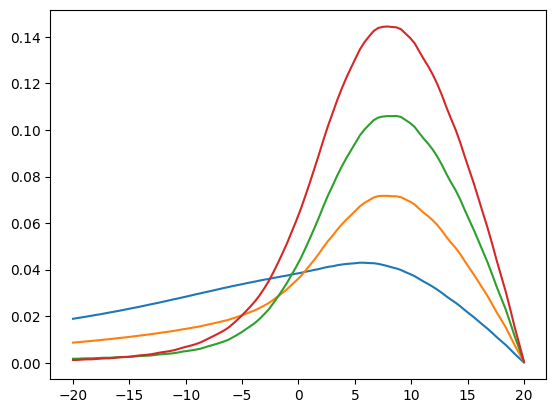

In [169]:
from joblib import Parallel, delayed

def compute_AGP_curve():
    o = [commute(P, sum([O(i, g) for i in range(1,L)])) for g in gs]
    return np.array([
        np.abs(np.vdot(psi_t[:, t], o[t] @ psi_t[:, t]))
        for t in range(N_timestep)
    ])
ns = [2,4,6,L]
for n in ns:
    P = Pn(n,"x",basis)
    AGP_all = compute_AGP_curve()

    plot(times, AGP_all, label=n)
    #legend()
    #show()


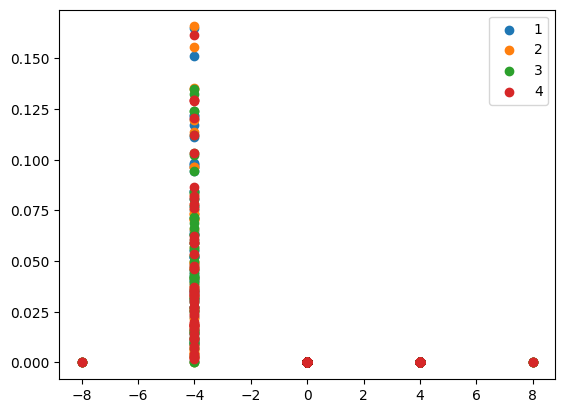

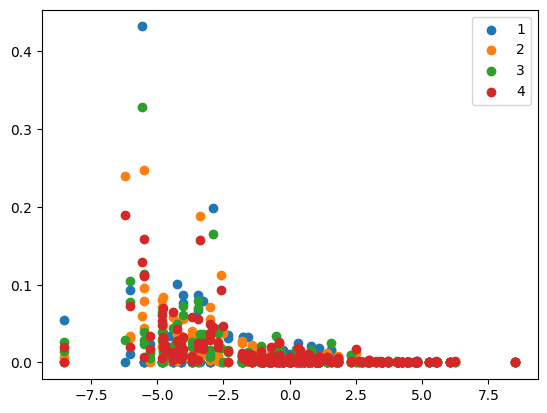

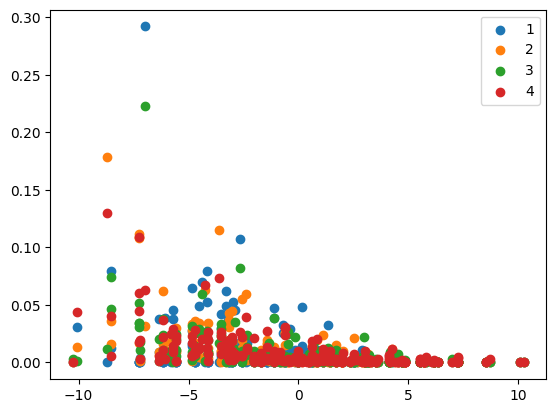

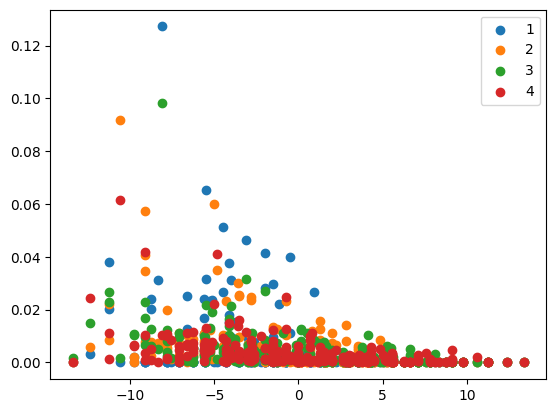

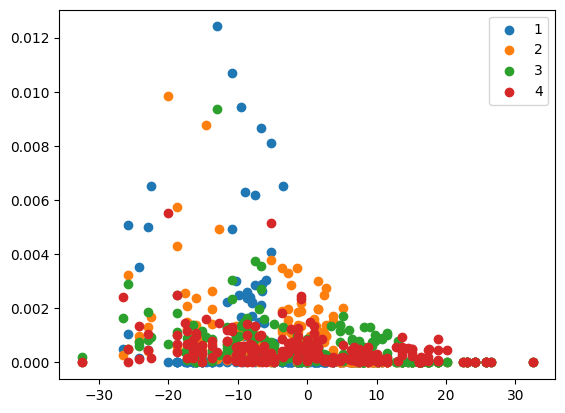

In [204]:
ns = [1,2,3,4]
o = [ sum([O(i, g) for i in range(1,L)]) for g in gs]

for g,og, Eg, Vg in zip(gs,o,energies,groundstates):
    for n in ns:
        P = Pn(n,"x",basis)
        og = commute(P,og)
        o_d = Vg.T@og@Vg
        o_d = o_d[:,0]
        scatter(Eg,np.abs(o_d),label=n)     
    legend()
    show()
    #yscale("log")

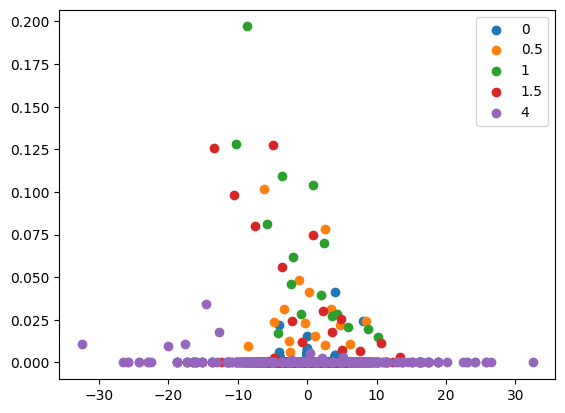

In [203]:
P= Pn(L,"z",basis)

o = [ commute(P,sum([O(i, g) for i in range(1,L)])) for g in gs]

for g,og, Eg, Vg in zip(gs,o,energies,groundstates):
    o_d = Vg.T@og@Vg
    o_d = o_d[:,0]
    scatter(Eg,np.abs(o_d),label=g)
legend()
    #yscale("log")

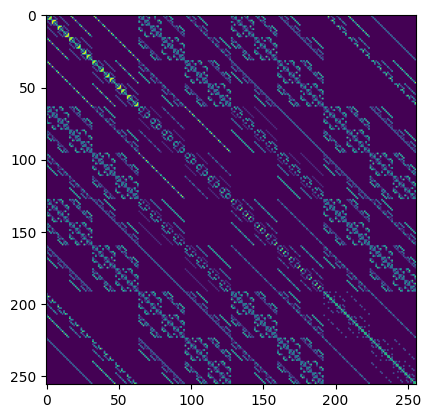

In [174]:
plt.imshow(np.abs(o[N_timestep//2]))